In [34]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

More tutorials on opencv can be found:

https://docs.opencv.org/master/d2/d96/tutorial_py_table_of_contents_imgproc.html

In [35]:
path = "tetris_blocks.png"

# Image input and initial processing
Load the input image (whose path was supplied via command line argument) and display the image to our screen:

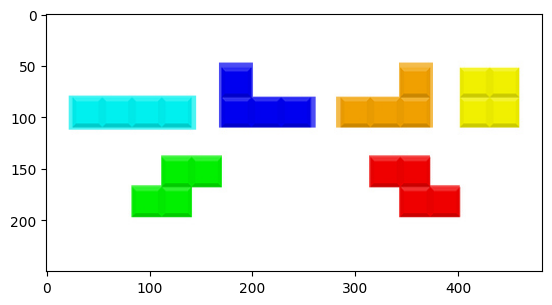

In [36]:
bgr_img = cv2.imread(path)
b,g,r = cv2.split(bgr_img)       # get b,g,r
image = cv2.merge([r,g,b])
plt.imshow(image)

Convert the image to grayscale:

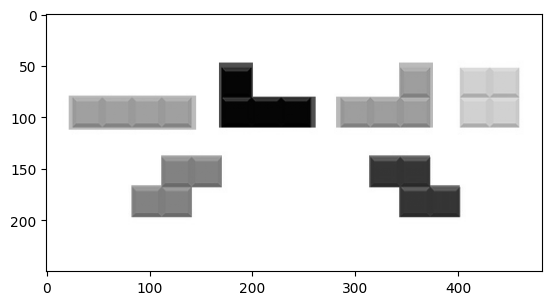

In [37]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap = 'gray')

# Advanced processing
Apply edge detection, so we can find the outlines of objects in images:


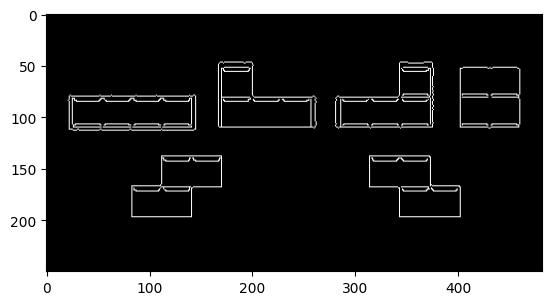

In [38]:
edged = cv2.Canny(gray, 30, 150)
plt.imshow(edged, cmap='gray')

Threshold the image by setting all pixel values equal to or less than 225 to 255 (white; foreground): $x \le 225 \rightarrow x = 255$ and all pixel values greater than 225 to 0 (black; background): $x \gt 225 \rightarrow x=0$

Thereby we are segmenting the image.

Both the threshold (e.g. 225 in our case) and the value for pixels less than the threshold in the resulting image (255 in our case) can be tweaked.

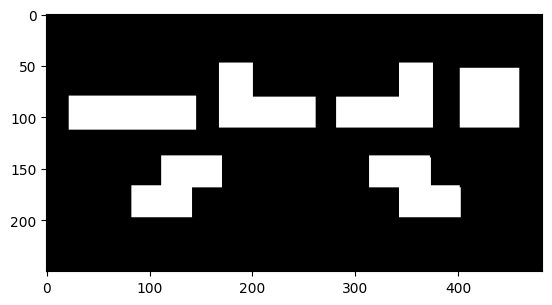

In [39]:
threshold = 225
threshold_value = 255

thresh = cv2.threshold(gray, threshold, threshold_value, cv2.THRESH_BINARY_INV)[1]
plt.imshow(thresh, cmap='gray')

Find contours (i.e., outlines) of the foreground objects in the thresholded image:

In [40]:
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
output = image.copy()

Loop over the contours:

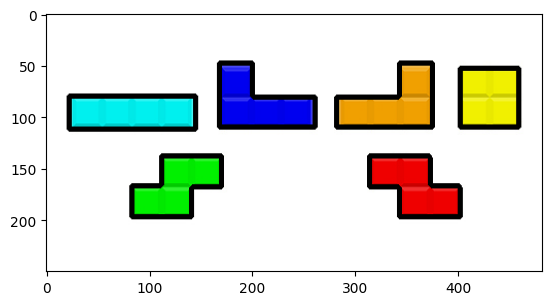

In [41]:
for c in cnts:
    # draw each contour on the output image with a 3px thick black outline
    cv2.drawContours(output, [c], -1, (0, 0, 0), 3)
    
plt.imshow(output)

Draw the total number of contours found in purple:

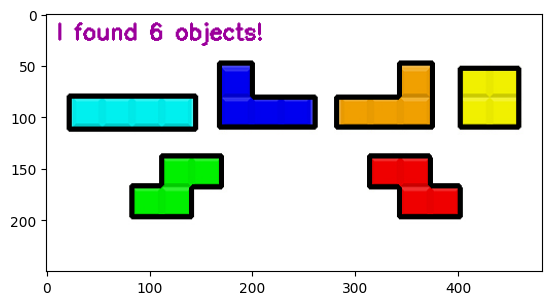

In [42]:
text = "I found {} objects!".format(len(cnts))
cv2.putText(output, text, (10, 25),  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (155, 0, 155), 2)
plt.imshow(output)

We apply erosions to reduce the size of foreground objects:

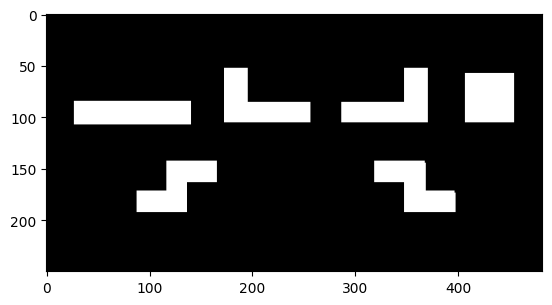

In [43]:
mask = thresh.copy()
mask = cv2.erode(mask, None, iterations = 5)
plt.imshow(mask, cmap = 'gray')

Similarly, dilations can increase the size of the ground objects:

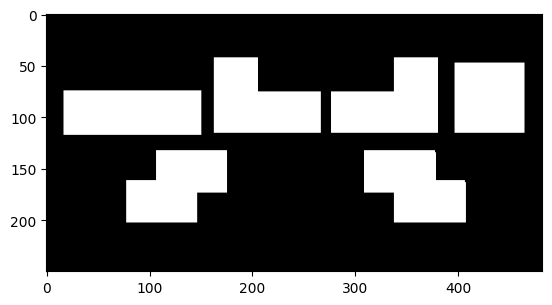

In [44]:
mask = thresh.copy()
mask = cv2.dilate(mask, None, iterations = 5)
plt.imshow(mask, cmap='gray')

A typical operation we may want to apply is to take our mask and apply a bitwise `AND` to our input image, keeping only the masked regions:

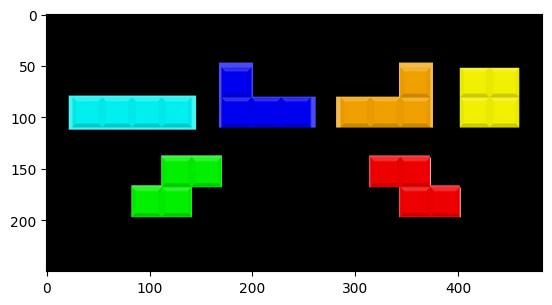

In [45]:
mask = thresh.copy()
output = cv2.bitwise_and(image, image, mask=mask)
plt.imshow(output)

# Exercise 2
1. Can you remove the yellow square from the image?
2. Go through the tutoria, but with the `spheres.png` image. (replace `tetris_blocks.png` with `spheres.png`)
3. Tweak the parameters of the thresholding. Can you threshold all the spheres?
4. Can you remove the red sphere?
5. Can you remove the green sphere?

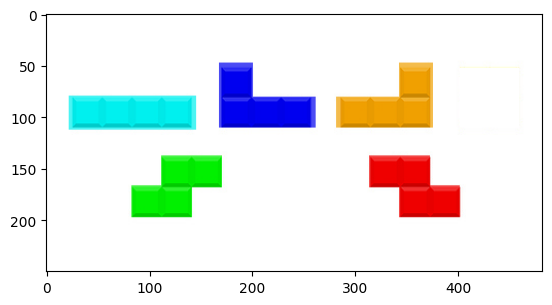

In [46]:
##1. Can you remove the yellow square from the image?
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

lower = np.array([25, 80, 120])  
upper = np.array([35, 255, 255])
mask = cv2.inRange(hsv, lower, upper)

result = image.copy()
result[mask > 0] = (255, 255, 255)

plt.imshow(result)

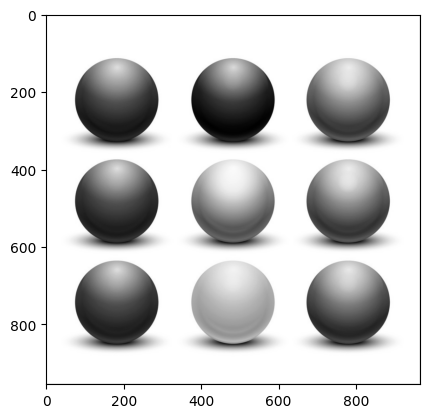

In [47]:
##2.Go through the tutoria, but with the `spheres.png` image. (replace `tetris_blocks.png` with `spheres.png`)
image1 = cv2.imread("spheres.png")
b,g,r = cv2.split(image1)       # get b,g,r
image1 = cv2.merge([r,g,b])
gray1 = cv2.cvtColor(image1, cv2.COLOR_RGB2GRAY)
plt.imshow(gray1, cmap = 'gray')


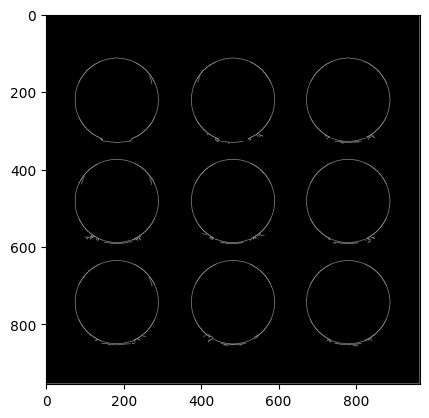

In [48]:
edged1 = cv2.Canny(gray1, 30, 120) 
plt.imshow(edged1, cmap='gray')

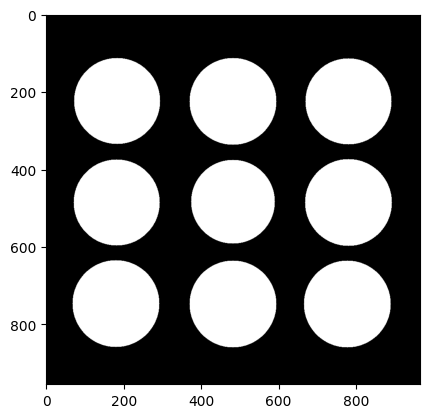

In [141]:
hsv1  = cv2.cvtColor(image1, cv2.COLOR_RGB2HSV)
mask1 = cv2.inRange(hsv1, (0,5,100), (179,255,235))    

# make spheres solid (fill highlight holes)
white_circles = cv2.morphologyEx(mask1, cv2.MORPH_CLOSE, np.ones((9,9),np.uint8), 1)

# make each sphere a perfect filled circle
cnts1, _ = cv2.findContours(white_circles, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
solid = np.zeros_like(white_circles)
for c in cnts1:
    (x,y), r = cv2.minEnclosingCircle(c)
    if 40 <= r <= 120:                    
        cv2.circle(solid, (int(x),int(y)), int(r), 255, -1)
        

plt.imshow(solid, cmap='gray')


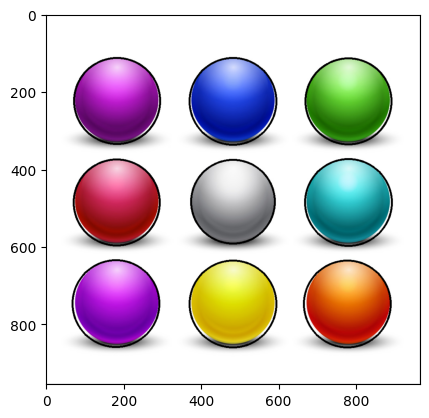

In [146]:
hsv1  = cv2.cvtColor(image1, cv2.COLOR_RGB2HSV)
mask1 = cv2.inRange(hsv1, (0,5,100), (179,255,235))    

# make spheres solid (fill highlight holes)
white_circles = cv2.morphologyEx(mask1, cv2.MORPH_CLOSE, np.ones((9,9),np.uint8), 1)

# make each sphere a perfect filled circle
cnts1, _ = cv2.findContours(white_circles, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output1 = image1.copy()
for c in cnts1:
    (x,y), r = cv2.minEnclosingCircle(c)
    if 40 <= r <= 120:                    
        cv2.circle(output1, (int(x),int(y)), int(r), (0, 0, 0), 3)

plt.imshow(output1)


9


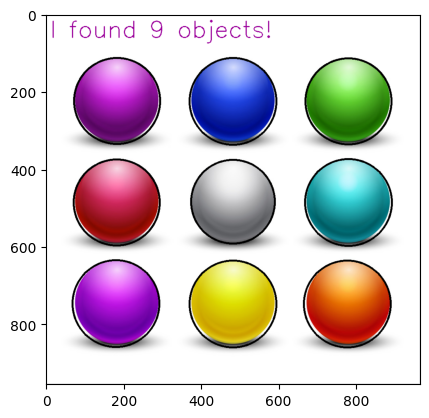

In [136]:
Spheres = sum(1 for c in cnts1 if 40 <= cv2.minEnclosingCircle(c)[1] <= 120)
print(Spheres)
text = "I found {} objects!".format(Spheres)
cv2.putText(output1, text, (10, 60),  cv2.FONT_HERSHEY_SIMPLEX, 2.0, (155, 0, 155), 2)
plt.imshow(output1)

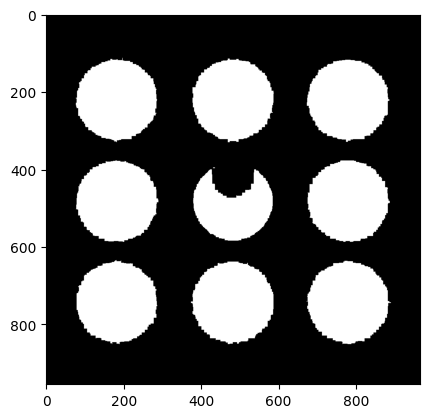

In [174]:
hsv1  = cv2.cvtColor(image1, cv2.COLOR_RGB2HSV)
mask1 = cv2.inRange(hsv1, (0,1,0), (255,255,255)) 
mask1 = cv2.erode(mask1, None, iterations = 5)
plt.imshow(mask1, cmap = 'gray')

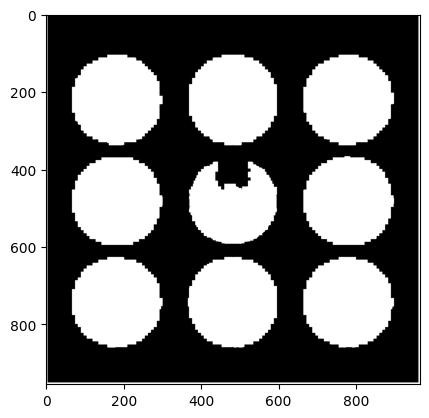

In [176]:
hsv1  = cv2.cvtColor(image1, cv2.COLOR_RGB2HSV)
mask1 = cv2.inRange(hsv1, (0,1,0), (255,255,255))   
mask1 = cv2.dilate(mask1, None, iterations = 3)
plt.imshow(mask1, cmap='gray')

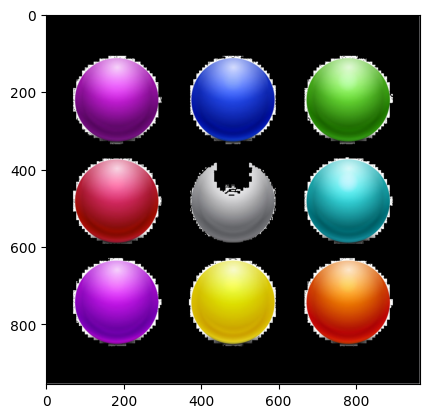

In [183]:
hsv1  = cv2.cvtColor(image1, cv2.COLOR_RGB2HSV)
mask1 = cv2.inRange(hsv1, (0,1,0), (255,255,255))
output1 = cv2.bitwise_and(image1, image1, mask=mask1)
plt.imshow(output1)

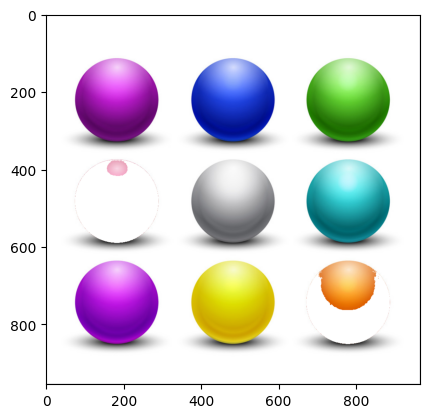

In [235]:
#3. Can you remove the red sphere from the image?
hsv1 = cv2.cvtColor(image1, cv2.COLOR_RGB2HSV)

mask_lo = cv2.inRange(hsv1, (0,80,80),   (10,255,255))   # low-red band
mask_hi = cv2.inRange(hsv1, (160,80,60), (179,255,255))  # high-red band
mask_red = mask_lo | mask_hi                              # combine bands

result = image1.copy()
result[mask_red > 0] = (255,255,255)

plt.imshow(result)